# Basic plotting with new weather observations
- testing to see if the graphs look correct
- to see if they will actually plot
- seeing for holes in data

In [1]:
import pandas as pd

path = "/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/weather_station_061055.csv"

df_1 = pd.read_csv(path)

df_1.head()

,timestamp_utc,temp,dewpoint,relative_humidity,wind_speed_kmh,wind_direction_deg,precip_incremental,lat,lon,station_name,station_id
0,2003-01-01 00:00:00+00:00,24.3,17.1,64.0,0.0,0.0,0.0,-32.9184,151.7985,NEWCASTLE NOBBYS SIGNAL STATION AWS,61055
1,2003-01-01 00:30:00+00:00,25.3,17.5,62.0,0.0,0.0,0.0,-32.9184,151.7985,NEWCASTLE NOBBYS SIGNAL STATION AWS,61055
2,2003-01-01 01:00:00+00:00,22.0,17.0,73.0,22.3,190.0,0.0,-32.9184,151.7985,NEWCASTLE NOBBYS SIGNAL STATION AWS,61055
3,2003-01-01 01:30:00+00:00,23.6,16.9,66.0,22.3,220.0,0.0,-32.9184,151.7985,NEWCASTLE NOBBYS SIGNAL STATION AWS,61055
4,2003-01-01 02:00:00+00:00,22.1,17.1,73.0,13.0,190.0,0.0,-32.9184,151.7985,NEWCASTLE NOBBYS SIGNAL STATION AWS,61055


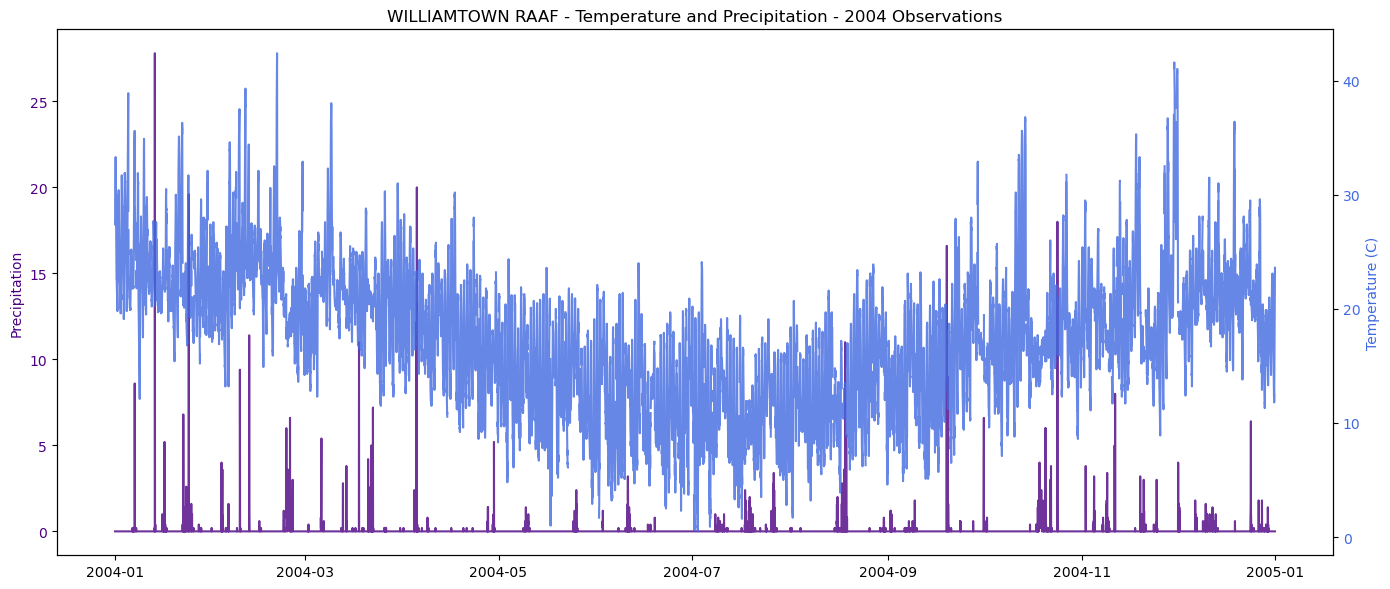

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed station file
path = "/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/weather_station_061078.csv"
df = pd.read_csv(path, parse_dates=["timestamp_utc"])

# Filter to 2004
df_2004 = df[df["timestamp_utc"].dt.year == 2004]

# Extract the station name (same for all rows)
station_name = df["station_name"].iloc[0].strip()


# Create figure
fig, ax1 = plt.subplots(figsize=(14,6))

# Precip left
ax1.plot(
    df_2004["timestamp_utc"],
    df_2004["precip_incremental"],
    color="indigo",
    alpha=0.8,
    label="Precipitation"
)
ax1.set_ylabel("Precipitation", color="indigo")
ax1.tick_params(axis="y", labelcolor="indigo")


# temperature right axis
ax2 = ax1.twinx()
ax2.plot(
    df_2004["timestamp_utc"],
    df_2004["temp"],
    color="royalblue",
    alpha=0.8,
    label="Temperature (C)"
)
ax2.set_ylabel("Temperature (C)", color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue")

# Title and layout
plt.title(f"{station_name} - Temperature and Precipitation - 2004 Observations")
plt.tight_layout()
plt.show()


# Trialing with demand and new data

In [3]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd /home/565/pv3484/aus_substation_electricity

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [4]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py


processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

In [5]:
demand.head()

,BLAKE,PUNCH,MEADO,MOSMA,RIVER,CA_CO,DU_HI,FI_DO,UMINA,CAMPS,...,LISAR,BEROW,HO_BA,SOMER,MORIS,WE_GO,WYONG,RUTHE,ROTHB,MUSWE
2004-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-01 00:30:00,11.77248,NaN,33.32921,26.86411,13.89570,23.07817,22.18987,15.14478,14.97165,28.97894,...,14.80155,15.49202,11.29188,6.80748,NaN,16.65575,12.23212,5.18215,NaN,9.24960
2004-01-01 01:00:00,10.40756,20.70845,30.79541,24.53589,11.52604,21.82337,20.55462,13.54961,17.09998,25.91148,...,16.72754,13.00451,11.47669,7.15043,NaN,18.55414,13.84397,4.32418,NaN,7.81060
2004-01-01 01:30:00,9.53552,19.09061,28.38565,22.76285,9.99050,20.53466,18.80529,12.44237,14.73313,23.68233,...,14.94422,11.04744,11.12555,6.22447,NaN,16.83484,12.07094,3.56669,NaN,6.56823
2004-01-01 02:00:00,8.39808,17.51083,26.50744,21.38383,8.39808,19.38160,17.60738,11.37266,11.99934,21.56750,...,13.16090,8.92574,11.36580,5.62432,NaN,15.15136,10.62028,3.10251,NaN,6.05148


## CSV I made with relative ranks has the lat/lon information included

In [6]:
import pandas as pd

rank = pd.read_csv(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv"
)

rank.head()

,year,holiday,holiday_group,is_holiday,station_code,station_name,lat,lon,date,weekday_name,...,20_24_mean,20_24_std,20_24_var,00_04_mean,00_04_std,00_04_var,residential,industrial,persons,dwellings
0,2004,New Year's Day,New Year's Day,True,BLAKE,Blakehurst,-33.9899,151.1086,2004-01-01,Thursday,...,0.2714,0.1402,0.0197,0.3191,0.0864,0.0075,0.85,0.021,28521,10081
1,2004,New Year's Day,New Year's Day,False,BLAKE,Blakehurst,-33.9899,151.1086,2004-01-02,Friday,...,0.4070,0.0224,0.0005,0.4360,0.0968,0.0094,0.85,0.021,28521,10081
2,2004,New Year's Day,New Year's Day,False,BLAKE,Blakehurst,-33.9899,151.1086,2004-01-03,Saturday,...,0.4214,0.0516,0.0027,0.3834,0.0519,0.0027,0.85,0.021,28521,10081
3,2004,New Year's Day,New Year's Day,False,BLAKE,Blakehurst,-33.9899,151.1086,2004-01-04,Sunday,...,0.3945,0.0303,0.0009,0.3969,0.0565,0.0032,0.85,0.021,28521,10081
4,2004,New Year's Day,New Year's Day,False,BLAKE,Blakehurst,-33.9899,151.1086,2004-01-05,Monday,...,0.4087,0.0163,0.0003,0.3107,0.0719,0.0052,0.85,0.021,28521,10081


In [7]:
#Extract weather‑station metadata from your processed CSVs

import pandas as pd
import glob

weather_files = glob.glob("/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/*.csv")

weather_meta = []
for f in weather_files:
    df = pd.read_csv(f, nrows=1)
    weather_meta.append({
        "station_id": df["station_id"].iloc[0],
        "station_name": df["station_name"].iloc[0].strip(),
        "lat": df["lat"].iloc[0],
        "lon": df["lon"].iloc[0],
        "file": f
    })

weather = pd.DataFrame(weather_meta)


In [8]:
#loading substation data

import pandas as pd

subs_unique = rank[["station_code", "station_name", "lat", "lon"]].drop_duplicates()


In [9]:
#compute nearest weather station for each substation - BallTree

from sklearn.neighbors import BallTree
import numpy as np

# Convert to radians
wx_coords = np.radians(weather[["lat", "lon"]].values)
sub_coords = np.radians(subs_unique[["lat", "lon"]].values)

# Build BallTree with haversine distance
tree = BallTree(wx_coords, metric="haversine")

dist, idx = tree.query(sub_coords, k=1)

subs_unique["nearest_station_id"] = weather.iloc[idx.flatten()]["station_id"].values
subs_unique["nearest_station_file"] = weather.iloc[idx.flatten()]["file"].values
subs_unique["distance_km"] = dist.flatten() * 6371  # convert radians to km


In [10]:
subs_unique.head()


,station_code,station_name,lat,lon,nearest_station_id,nearest_station_file,distance_km
0,BLAKE,Blakehurst,-33.9899,151.1086,66037,/home/565/pv3484/aus_substation_electricity/da...,7.659590
30,PUNCH,Punchbowl,-33.9287,151.0523,66194,/home/565/pv3484/aus_substation_electricity/da...,6.190918
60,MEADO,Meadowbank,-33.8175,151.0884,66212,/home/565/pv3484/aus_substation_electricity/da...,2.374109
90,MOSMA,Mosman,-33.8284,151.2477,66196,/home/565/pv3484/aus_substation_electricity/da...,2.039876
120,RIVER,Riverwood,-33.9472,151.0531,66137,/home/565/pv3484/aus_substation_electricity/da...,7.199153


## Plotting blakehurst relative ranked demand and humidity ANZAC day 2007

In [34]:
#identify blakehurst nearest weather station
sub_id = "BLAKE"

wx_file = subs_unique.loc[
    subs_unique["station_code"] == sub_id,
    "nearest_station_file"
].iloc[0]


In [35]:
#loading weather data and filter to ANZAC day 2007

import pandas as pd

wx = pd.read_csv(wx_file, parse_dates=["timestamp_utc"])
wx["date"] = wx["timestamp_utc"].dt.date

anzac = pd.to_datetime("2007-04-25").date()
wx_day = wx[wx["date"] == anzac]


In [36]:
# loading blakehurst demand for anzac day 2007

rank["date"] = pd.to_datetime(rank["date"]).dt.date

rank_blake = rank[
    (rank["station_code"] == "BLAKE") &
    (rank["date"] == anzac)
].iloc[0]

d00_04 = rank_blake["00_04_mean"]
d04_10 = rank_blake["04_10_mean"]
d10_15 = rank_blake["10_15_mean"]
d15_20 = rank_blake["15_20_mean"]
d20_24 = rank_blake["20_24_mean"]


In [37]:
#build demand-time sercies aligned to weather timestamps

import numpy as np

demand_series = []

for ts in wx_day["timestamp_utc"]:
    hour = ts.hour
    if 0 <= hour < 4:
        demand_series.append(d00_04)
    elif 4 <= hour < 10:
        demand_series.append(d04_10)
    elif 10 <= hour < 15:
        demand_series.append(d10_15)
    elif 15 <= hour < 20:
        demand_series.append(d15_20)
    else:
        demand_series.append(d20_24)

wx_day["demand_block"] = demand_series


/jobfs/163173172.gadi-pbs/ipykernel_3791641/1591136298.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wx_day["demand_block"] = demand_series


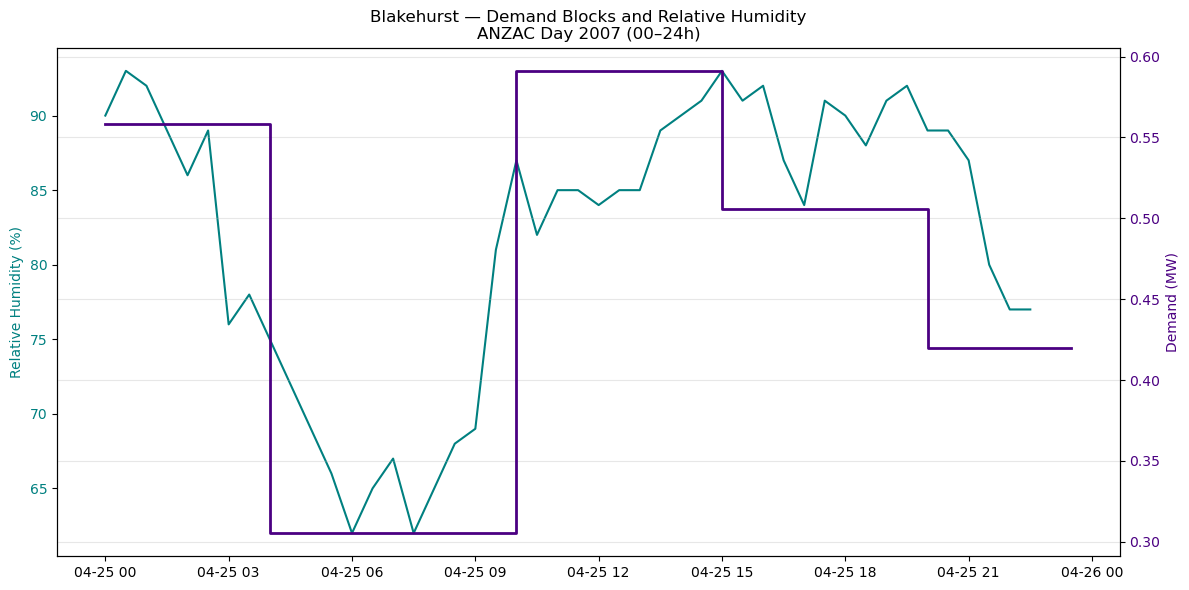

In [38]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Relative humidity (line)
ax1.plot(
    wx_day["timestamp_utc"],
    wx_day["relative_humidity"],
    color="teal",
    label="Relative Humidity (%)"
)
ax1.set_ylabel("Relative Humidity (%)", color="teal")
ax1.tick_params(axis="y", labelcolor="teal")

# Demand blocks (step function)
ax2 = ax1.twinx()
ax2.step(
    wx_day["timestamp_utc"],
    wx_day["demand_block"],
    where="post",
    color="indigo",
    linewidth=2,
    label="Demand (block means)"
)
ax2.set_ylabel("Demand (MW)", color="indigo")
ax2.tick_params(axis="y", labelcolor="indigo")

plt.title("Blakehurst — Demand Blocks and Relative Humidity\nANZAC Day 2007 (00–24h)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Plotting raw demand 2007 ANZAC day blakehurst vs humidity

In [39]:
#renaming time index for demand to plot

#demand = demand.reset_index()
#demand.head()
demand = demand.rename(columns={"index": "timestamp_utc"})


In [40]:
#wx["timestamp_utc"] = wx["timestamp_utc"].dt.tz_localize(None)
wx["timestamp_utc"].dtype


datetime64[ns, UTC]

In [41]:
demand["timestamp_utc"] = demand["timestamp_utc"].dt.tz_localize(None)


KeyError: 'timestamp_utc'

In [23]:
demand["timestamp_utc"].dtype

KeyError: 'timestamp_utc'

In [24]:
wx["timestamp_utc"].dtype


datetime64[ns, UTC]

In [28]:
# 1. Rebuild demand_day from the cleaned demand DataFrame
anzac = pd.to_datetime("2007-04-25").date()

demand_day = demand[
    demand["timestamp_utc"].dt.date == anzac
][["timestamp_utc", "BLAKE"]].rename(columns={"BLAKE": "demand_raw"})


KeyError: 'timestamp_utc'

In [26]:
wx_day = wx[
    wx["timestamp_utc"].dt.date == anzac
][["timestamp_utc", "relative_humidity"]]


In [27]:
merged = demand_day.merge(
    wx_day,
    on="timestamp_utc",
    how="inner"
)


NameError: name 'demand_day' is not defined

NameError: name 'merged' is not defined

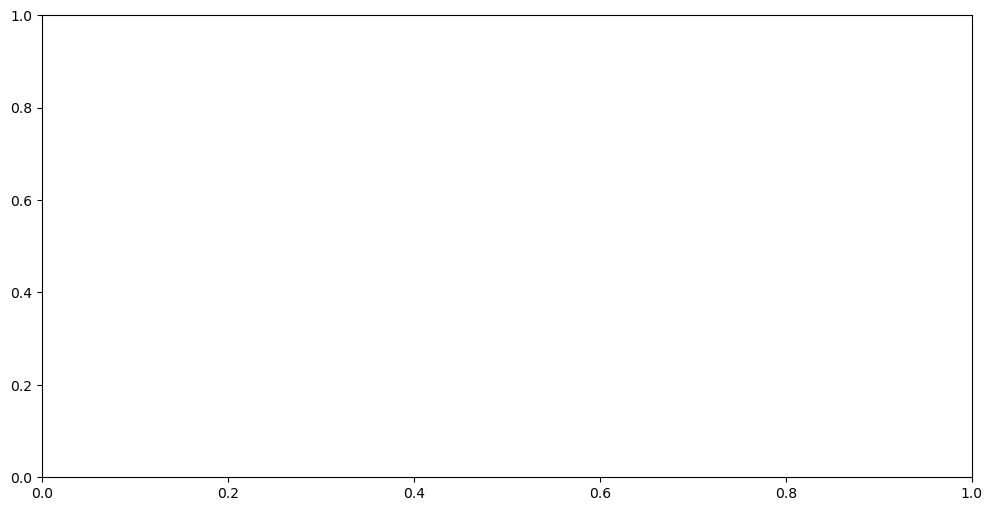

In [29]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Raw demand (left axis)
ax1.plot(
    merged["timestamp_utc"],
    merged["demand_raw"],
    color="indigo",
    linewidth=2,
    label="Raw Demand (MW)"
)
ax1.set_ylabel("Demand (MW)", color="indigo")
ax1.tick_params(axis="y", labelcolor="indigo")

# Relative humidity (right axis)
ax2 = ax1.twinx()
ax2.plot(
    merged["timestamp_utc"],
    merged["relative_humidity"],
    color="teal",
    alpha=0.7,
    linewidth=2,
    label="Relative Humidity (%)"
)
ax2.set_ylabel("Relative Humidity (%)", color="teal")
ax2.tick_params(axis="y", labelcolor="teal")

plt.title("Blakehurst — Raw Demand and Relative Humidity\nANZAC Day 2007 (00–24h)")
plt.xlabel("Time (UTC)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Plotting demand vs precipitation

In [30]:
wx_day = wx[
    wx["timestamp_utc"].dt.date == anzac
][["timestamp_utc", "precip_incremental"]]


In [31]:
wx_day = wx_day.rename(columns={"precip_incremental": "precip"})


In [32]:
merged = demand_day.merge(wx_day, on="timestamp_utc", how="inner")


NameError: name 'demand_day' is not defined

NameError: name 'merged' is not defined

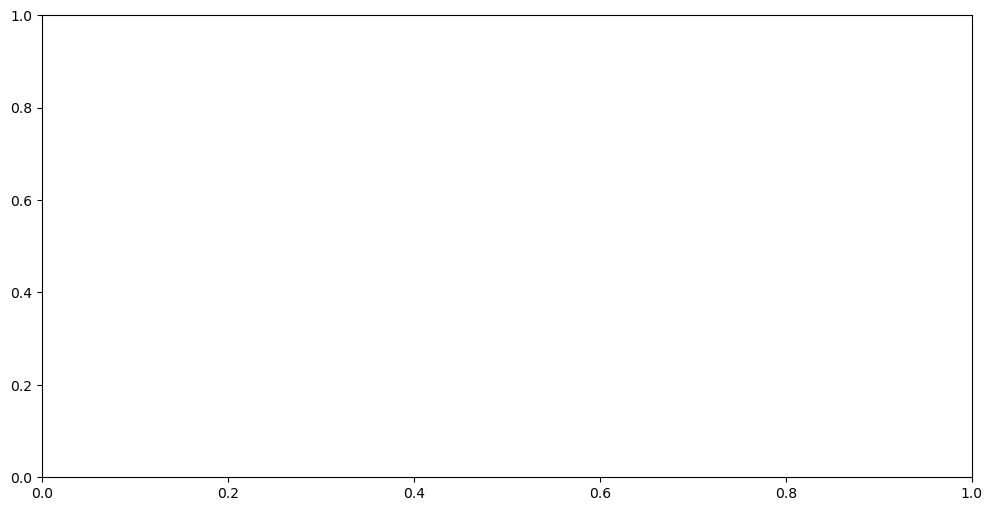

In [33]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Demand
ax1.plot(
    merged["timestamp_utc"],
    merged["demand_raw"],
    color="indigo",
    linewidth=2
)
ax1.set_ylabel("Demand (MW)", color="indigo")
ax1.tick_params(axis="y", labelcolor="indigo")

# Precipitation
ax2 = ax1.twinx()
ax2.bar(
    merged["timestamp_utc"],
    merged["precip"],
    width=0.02,
    color="cadetblue",
    alpha=0.6
)
ax2.set_ylabel("Precipitation (mm)", color="cadetblue")
ax2.tick_params(axis="y", labelcolor="cadetblue")

plt.title("Blakehurst — Raw Demand and Precipitation\nANZAC Day 2007")
plt.xlabel("Time (UTC)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
